In [12]:
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from scipy.stats import norm

### Loading the data

In [13]:
x=np.load("formationchannels.npy")
np.random.seed(3)

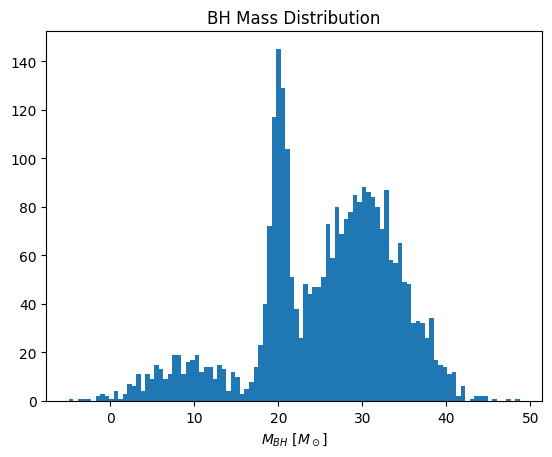

In [14]:
plt.xlabel(r'$M_{BH} \ [M_\odot]$')
plt.title('BH Mass Distribution')
plt.hist(x, bins=100);

It looks like there are 3 modes, one centered around $10 \ [M_\odot]$, one around $20 \ [M_\odot]$ and one around $30 \ [M_\odot]$

### AIC

In [15]:
N=[1,2,3,4,5,6,7,8,9,10]
AIC_array=np.array([])
for i in range(len(N)):
    gm=sklearn.mixture.GaussianMixture(N[i])
    z=gm.fit(X=x, y=None)
    AIC=gm.aic(x)
    AIC_array=np.append(AIC_array,AIC)

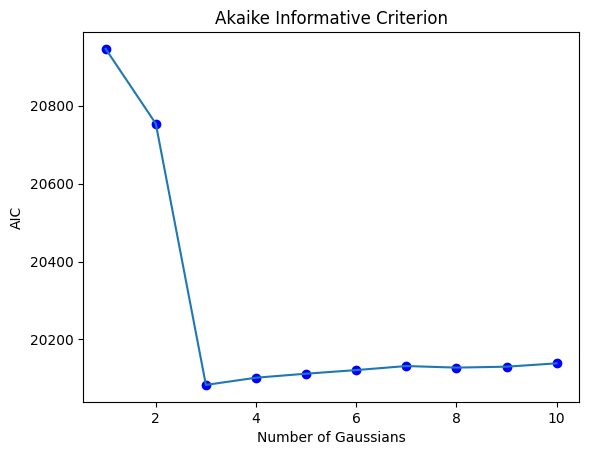

In [16]:
plt.plot(N,AIC_array)
plt.scatter(N,AIC_array, c='b')
plt.title("Akaike Informative Criterion")
plt.ylabel("AIC")
plt.xlabel("Number of Gaussians");

### Bestfit

In [17]:
bestfit=N[np.argmin(AIC_array)]

gm_fit=sklearn.mixture.GaussianMixture(bestfit)
z_fit=gm_fit.fit(X=x, y=None)
mu=z_fit.means_
weights=z_fit.weights_
sigma=np.sqrt(z_fit.covariances_)

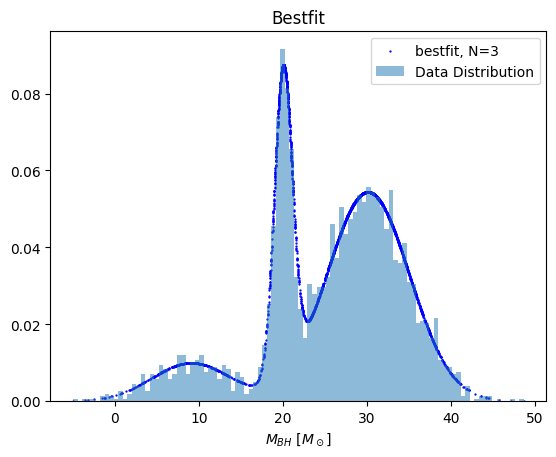

In [18]:
data=np.array([0]*len(x))
aa=np.array([])
for i in range(len(mu)):
    dist=norm(mu[i],sigma[i])
    y=dist.pdf(x)*weights[i]
    aaa=np.append(aa,y)
    data=data+aaa

plt.xlabel(r'$M_{BH} \ [M_\odot]$')
plt.title('Bestfit')
plt.scatter(x,data,s=0.4, label='bestfit, N='+str(bestfit), c='b')
plt.hist(x, bins=100, alpha=0.5, density='True', label='Data Distribution')
plt.legend(loc='upper right');

# OPTIONAL

### Responsibilities

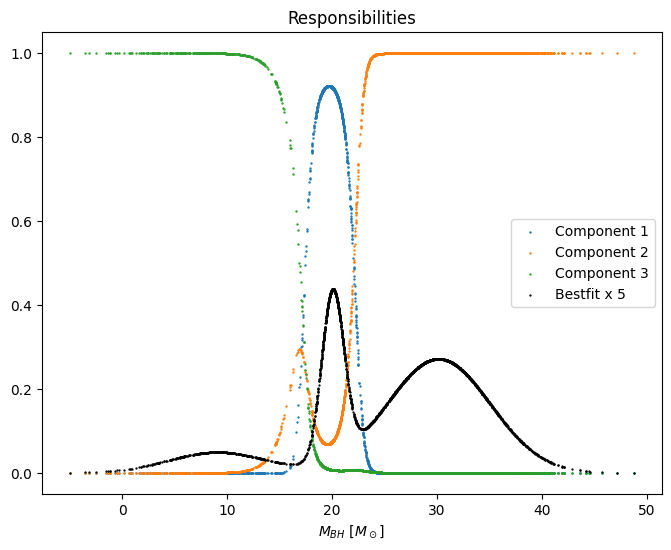

In [19]:
plt.figure(figsize=[8,6])
X=[x,np.newaxis]
y=gm_fit.predict_proba(x)

plt.scatter(x,y[:,0], s=0.5, label='Component 1')
plt.scatter(x,y[:,1], s=0.5, label='Component 2')
plt.scatter(x,y[:,2], s=0.5, label='Component 3')

plt.xlabel(r'$M_{BH} \ [M_\odot]$')
plt.title('Responsibilities')

plt.scatter(x,data*5,s=0.4, label='Bestfit x 5', c='k')

plt.legend(loc='best');

### Other (worse) fits

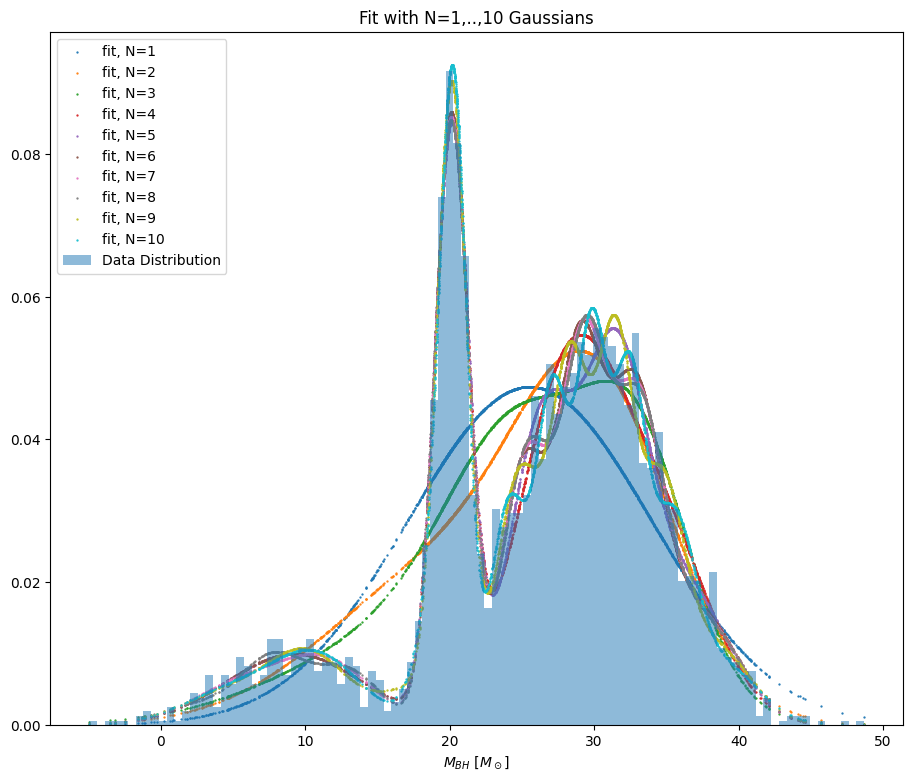

In [20]:
fig = plt.figure(figsize=(11,9))
for j in range(len(N)):
    gm_fit=sklearn.mixture.GaussianMixture(N[j])
    z_fit=gm_fit.fit(X=x, y=None)
    mu=z_fit.means_
    weights=z_fit.weights_
    sigma=np.sqrt(z_fit.covariances_)
    
    data=np.array([0]*len(x))
    aa=np.array([])
    for i in range(len(mu)):
        dist=norm(mu[i],sigma[i])
        y=dist.pdf(x)*weights[i]
        aaa=np.append(aa,y)
        data=data+aaa
    plt.scatter(x,data,s=0.4, label='fit, N='+str(N[j]))


plt.xlabel(r'$M_{BH} \ [M_\odot]$')
plt.title('Fit with N=1,..,10 Gaussians')
plt.hist(x, bins=100, alpha=0.5, density='True', label='Data Distribution')
plt.legend(loc='upper left');